In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Display plots inside Colab
%matplotlib inline

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nInformation:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nAttrition Count:")
print(df["Attrition"].value_counts())

Shape of Dataset:
(1470, 35)

Column Names:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age        

**Dataset Overview**
*   Dataset contains 1470 employees and 35 features.
*   No missing values were found.
*   The target variable is Attrition, indicating whether an employee left the company.







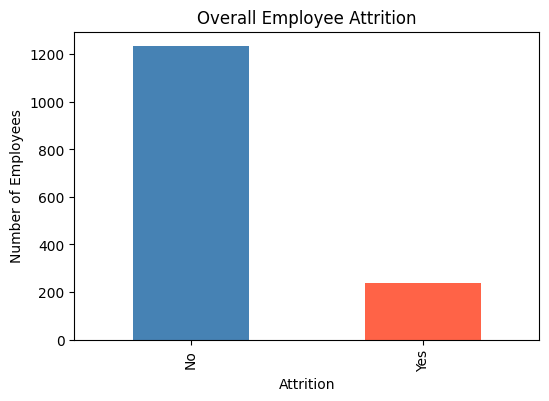

In [5]:
plt.figure(figsize=(6,4))

df["Attrition"].value_counts().plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.title("Overall Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

**Finding**
*   Most employees stayed with the company.
*   Around 16% of employees left, indicating moderate employee attrition.



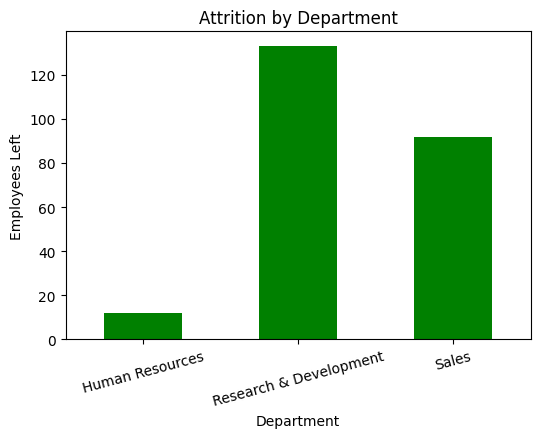

In [6]:
dept = df.groupby("Department")["Attrition"].apply(lambda x:(x=="Yes").sum())

plt.figure(figsize=(6,4))

dept.plot(
    kind="bar",
    color="green"
)

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employees Left")

plt.xticks(rotation=15)

plt.show()

**Finding**
*   Sales department has the highest number of employees leaving.
*   HR has the lowest attrition count.

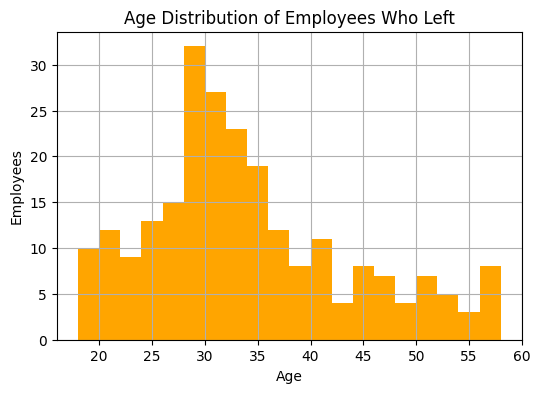

In [7]:
plt.figure(figsize=(6,4))

df[df["Attrition"]=="Yes"]["Age"].hist(
    bins=20,
    color="orange"
)

plt.title("Age Distribution of Employees Who Left")
plt.xlabel("Age")
plt.ylabel("Employees")

plt.show()

**Finding**
*   Most employees who left are between 25–35 years old.
*   Younger employees tend to leave more frequently.




<Figure size 600x400 with 0 Axes>

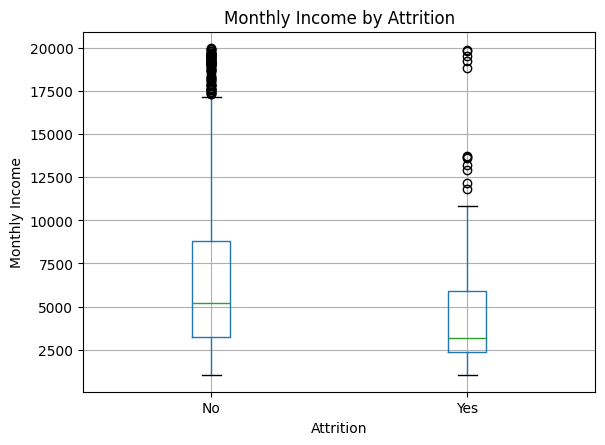

In [8]:
plt.figure(figsize=(6,4))

df.boxplot(
    column="MonthlyIncome",
    by="Attrition"
)

plt.title("Monthly Income by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

**Finding**
*  Employees who left generally earned lower salaries.
*  Higher income employees were more likely to stay.



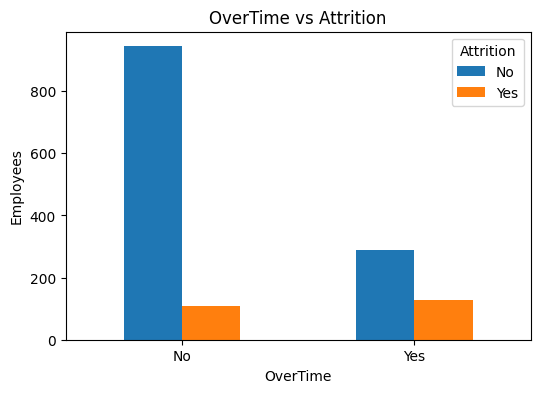

In [9]:
ot = df.groupby(["OverTime","Attrition"]).size().unstack()

ot.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Employees")

plt.xticks(rotation=0)

plt.show()

**Finding**
*   Employees working overtime had noticeably higher attrition.
*   Overtime appears to be a strong factor in employee turnover.




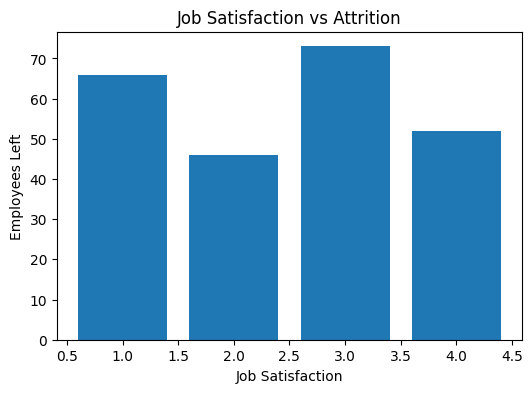

In [10]:
js = df.groupby("JobSatisfaction")["Attrition"].apply(lambda x:(x=="Yes").sum())

plt.figure(figsize=(6,4))

plt.bar(
    js.index,
    js.values
)

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Employees Left")

plt.show()

Finding

*   Employees with lower job satisfaction levels show higher attrition.
*   Improving employee satisfaction may reduce turnover.

In [11]:
plt.savefig("hr_attrition_analysis.png")

<Figure size 640x480 with 0 Axes>

**Overall Findings**

• Employee attrition rate is around 16%.

• Sales department experiences the highest attrition.

• Younger employees are more likely to leave.

• Employees working overtime have significantly higher attrition.

• Lower monthly income is associated with higher employee turnover.

• Employees with low job satisfaction tend to leave more frequently.